# Kalman Filter vs. MCMC for Financial Time Series

The earlier notebooks all assumed the relationship between predictors and target was **fixed**: a single coefficient vector, estimated once from a training window. This notebook drops that assumption and asks: when the true relationship actually **drifts over time**, what's the right way to estimate it?

Two very different frameworks are compared:

1. **The Kalman filter** — a recursive, closed-form algorithm that treats the coefficients themselves as a hidden, evolving *state* and updates them online, one observation at a time.
2. **MCMC (Markov Chain Monte Carlo)** — a simulation-based Bayesian framework that approximates the full *posterior distribution* of the coefficients, explored here via three complementary samplers: **Gibbs sampling**, **Metropolis-Hastings**, and **Adaptive Metropolis**.

Both are then applied to the same task as before: predicting cumulative returns out of sample over the next 250 trading days. A follow-up section then **combines the two**, using MCMC to put a full posterior — not just a point estimate — on the Kalman filter's own hyperparameters.

## 1. The Kalman Filter: Theory and Optimization Framework

**The model.** A *state-space* (dynamic linear) model separates a hidden, evolving state $\beta_t$ (here, the true regression coefficients) from what's actually observed:

$$\text{State equation:}\quad \beta_t = \beta_{t-1} + w_t, \qquad w_t \sim \mathcal{N}(0, Q)$$
$$\text{Observation equation:}\quad y_t = x_t^\top \beta_t + v_t, \qquad v_t \sim \mathcal{N}(0, R)$$

$\beta_t$ is never observed directly — only $y_t$ is. $Q$ (process noise) controls how fast the true coefficients are allowed to drift; $R$ (observation noise) is the day-to-day noise in the target itself.

**The optimization framework.** At each step, the Kalman filter computes the estimate of $\beta_t$ that **minimizes the mean squared error** of the state estimate, given everything observed so far — this is provably the optimal linear estimator under the Gaussian assumptions above. It does this recursively in two steps:

- **Predict:** project the previous estimate forward, $\hat\beta_{t|t-1} = \hat\beta_{t-1}$, $P_{t|t-1} = P_{t-1} + Q$ (the covariance grows — the state becomes less certain since it may have drifted).
- **Update:** once $y_t$ arrives, correct the prediction using the *Kalman gain* $K_t$, which is itself the solution to a least-squares optimization (it's chosen to minimize the posterior variance of $\hat\beta_t$):

$$K_t = P_{t|t-1}\,x_t \,/\, S_t, \qquad S_t = x_t^\top P_{t|t-1}\, x_t + R$$
$$\hat\beta_t = \hat\beta_{t|t-1} + K_t\,(y_t - x_t^\top\hat\beta_{t|t-1}), \qquad P_t = P_{t|t-1} - K_t\, x_t^\top P_{t|t-1}$$

Unlike every model in the previous notebooks, this produces a genuinely **online** estimator: $\hat\beta_t$ updates with each new observation, rather than being fit once on a training window and then frozen.

**Limitations.** The filter is only optimal if the linear-Gaussian assumptions hold; non-linear or heavy-tailed dynamics need an Extended/Unscented Kalman filter or a particle filter instead. It also requires $Q$ and $R$ to be specified — getting them wrong causes the filter to either over-react to noise (too much $Q$) or fail to track real drift (too little $Q$). As Section 3 below shows, **estimating $Q$ reliably from data is itself a real practical challenge.**

## 2. MCMC: Theory and Optimization Framework

**The goal is different from optimization.** Bayesian inference wants the full posterior distribution $p(\beta, \sigma^2 \mid y) \propto p(y \mid \beta,\sigma^2)\, p(\beta,\sigma^2)$ — not a single best-fit point, but a distribution capturing everything the data and prior imply about plausible parameter values. For anything beyond the simplest models, this posterior has no closed form. **MCMC constructs a Markov chain whose stationary distribution is exactly that posterior**, then runs it long enough that the samples it produces can stand in for draws from the posterior itself. It is a *sampling* algorithm, not an optimization — though, as below, tuning one for efficiency is itself a small optimization problem.

Three complementary samplers are used here, all targeting the same Bayesian linear regression posterior (Normal prior on $\beta$, Inverse-Gamma prior on $\sigma^2$):

**Gibbs sampling.** When the full *conditional* distributions are known in closed form, Gibbs sampling draws from them one at a time, cycling through:
$$\beta \mid \sigma^2, y \;\sim\; \mathcal{N}(\mu_n, \Sigma_n), \qquad \sigma^2 \mid \beta, y \;\sim\; \text{Inv-Gamma}(a_n, b_n)$$
Every proposed draw is automatically accepted (there's no accept/reject step), so when conjugacy is available, Gibbs sampling is typically the most efficient option.

**Metropolis-Hastings (MH).** The general-purpose fallback when full conditionals aren't tractable: propose a random step $\theta' = \theta + \epsilon$, $\epsilon \sim \mathcal{N}(0, \Sigma_{\text{prop}})$, and accept it with probability $\min\!\big(1,\, p(\theta'\mid y)/p(\theta\mid y)\big)$. The proposal scale $\Sigma_{\text{prop}}$ has to be *tuned*: too small and the chain barely moves (high acceptance, slow exploration); too large and almost every proposal is rejected (low acceptance, the chain gets stuck). The classic guideline targets an acceptance rate near **0.234** in higher dimensions.

**Adaptive Metropolis (Haario et al., 2001).** Rather than hand-tuning $\Sigma_{\text{prop}}$, this scales it automatically from the chain's own running covariance, $\Sigma_{\text{prop}} = s_d \cdot \widehat{\text{Cov}}(\theta_{1:t}) $, with the theoretically optimal scale $s_d = 2.4^2/d$. This removes the manual tuning burden of plain MH, at the cost of a slightly more delicate implementation (the adaptation itself has to be handled carefully to keep the chain's target distribution unchanged).

**Other approaches (not implemented here, for context).** **Hamiltonian Monte Carlo / NUTS** uses the gradient of the log-posterior to make long, informed proposals, dramatically improving mixing in high dimensions (the engine behind modern tools like Stan/PyMC). **Particle MCMC / Sequential Monte Carlo** extend MCMC to genuinely sequential, online Bayesian updating for state-space models — the natural bridge between the Kalman filter's online character and MCMC's flexibility (revisited in Section 8). **Reversible-jump MCMC** allows the sampler to move between models of different dimension, useful for Bayesian variable selection.

**Limitations of MCMC generally.** It's computationally expensive — thousands of iterations, most spent on a "burn-in" period before the chain reaches its stationary distribution. Consecutive samples are autocorrelated, so the *effective* sample size is well below the raw iteration count (quantified below). Convergence has to be diagnosed (trace plots, acceptance rates, effective sample size) rather than guaranteed. And it scales poorly to very high dimensions — a genuine constraint, which is why this notebook works with a small, pre-selected set of predictors rather than the full 400-asset universe from before.

## 3. A Market with Drifting Relationships

This builds directly on the double-selection result from the previous notebook: the same 6 assets identified there as genuine predictors are used again as the feature set — but this time, their **true influence is allowed to drift**, via a slow random walk, rather than staying fixed for the full 8 years. This is exactly the situation the Kalman filter is built for, and exactly the situation a static estimator (OLS, or MCMC with a fixed-coefficient prior) cannot adapt to.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    'figure.figsize': (7, 4.2), 'font.size': 11,
    'axes.titlesize': 13, 'axes.titleweight': 'bold',
    'axes.labelsize': 11, 'grid.alpha': 0.35,
})

rng = np.random.default_rng(11)

# Same 400-asset universe as the previous notebooks
n_sectors, sector_size = 20, 20
N = n_sectors * sector_size
sectors = np.repeat([f"S{i+1}" for i in range(n_sectors)], sector_size)
corr = np.full((N, N), 0.08)
for s in range(n_sectors):
    idx = np.where(sectors == f"S{s+1}")[0]
    corr[np.ix_(idx, idx)] = 0.45
np.fill_diagonal(corr, 1.0)
vols = rng.uniform(0.10, 0.30, N)
cov_annual = np.outer(vols, vols) * corr
mu_annual = rng.uniform(0.02, 0.10, N)
n_days = 8 * 252
dt = 1 / 252
R = rng.multivariate_normal(mu_annual * dt, cov_annual * dt, size=n_days)

# The 6 leaders identified by double-selection Lasso previously
leader_idx = [3, 55, 130, 210, 305, 370]
beta0 = np.array([0.9, -0.8, 1.0, -0.9, 0.85, -0.75])
n_leaders = len(leader_idx)

X_leaders = R[:-1][:, leader_idx]
n_obs = X_leaders.shape[0]

# True coefficients now follow a slow random walk rather than staying fixed
process_std_true = 0.01
drift = np.cumsum(np.random.default_rng(42).normal(0, process_std_true, size=(n_obs, n_leaders)), axis=0)
beta_t_true = beta0[None, :] + drift

signal = np.einsum('td,td->t', X_leaders, beta_t_true)
snr = 0.25
noise_std = signal.std() * np.sqrt((1 - snr) / snr)
y_all = signal + np.random.default_rng(43).normal(0, noise_std, size=n_obs)

n_test = 250
n_train = n_obs - n_test
Xtr, Xte = X_leaders[:n_train], X_leaders[n_train:]
ytr, yte = y_all[:n_train], y_all[n_train:]

print(f"Predictors: {n_leaders} (pre-selected)  |  Train: {n_train} days  |  Test: {n_test} days")
print(f"True coefficient drift, max |change| from day 0: {np.max(np.abs(drift), axis=0).round(2)}")

Predictors: 6 (pre-selected)  |  Train: 1765 days  |  Test: 250 days
True coefficient drift, max |change| from day 0: [0.36 0.83 0.98 0.49 0.42 0.52]


**Diagram — the drift itself.** Each leader's true coefficient wanders meaningfully over the 8-year span; a coefficient estimated once from early data would be stale by the end.

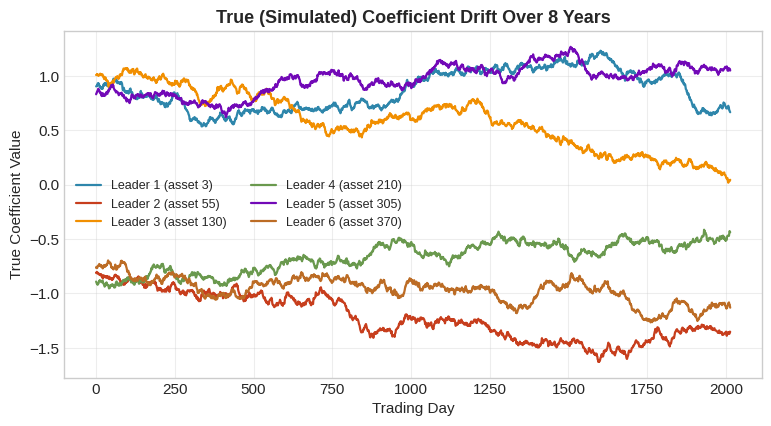

In [ ]:
fig, ax = plt.subplots(figsize=(9, 4.5))
colors6 = ['#2E86AB', '#C73E1D', '#F18F01', '#6A994E', '#7209B7', '#BC6C25']
for i in range(n_leaders):
    ax.plot(beta_t_true[:, i], color=colors6[i], linewidth=1.6, label=f'Leader {i+1} (asset {leader_idx[i]})')
ax.set_xlabel('Trading Day'); ax.set_ylabel('True Coefficient Value')
ax.set_title('True (Simulated) Coefficient Drift Over 8 Years')
ax.legend(ncol=2, fontsize=9)
plt.show()

## 4. Fitting the Kalman Filter

### 4.1 Implementation

In [ ]:
def kalman_filter_dlm(X, y, Q, R_obs, beta0_prior=None, P0=None):
    # Recursive dynamic linear regression: beta_t = beta_{t-1} + w_t,  y_t = x_t . beta_t + v_t
    n, d = X.shape
    if beta0_prior is None: beta0_prior = np.zeros(d)
    if P0 is None: P0 = np.eye(d) * 10.0
    beta_est, P = beta0_prior.copy(), P0.copy()
    beta_history, pred_history = np.zeros((n, d)), np.zeros(n)
    Qmat = np.eye(d) * Q
    for t in range(n):
        beta_pred, P_pred = beta_est, P + Qmat                 # predict
        x_t = X[t]
        y_pred = x_t @ beta_pred
        S = x_t @ P_pred @ x_t + R_obs                          # innovation variance
        K = (P_pred @ x_t) / S                                  # Kalman gain
        innovation = y[t] - y_pred
        beta_est = beta_pred + K * innovation                   # update
        P = P_pred - np.outer(K, x_t) @ P_pred
        beta_history[t], pred_history[t] = beta_est, y_pred
    return beta_history, pred_history

### 4.2 Choosing $Q$ and $R$

A natural first instinct is to choose $Q$ and $R$ by maximizing the filter's own likelihood on the training data. In practice this often **fails here**: with observation noise this large relative to the true drift, the likelihood is nearly flat in $Q$, and unconstrained maximization collapses $Q \to 0$ — effectively declaring the coefficients static, even though they aren't. This is a genuine, well-known identifiability problem, not a bug.

Instead, $Q$ is chosen by a small grid search that holds out the *last portion of the training period* as a validation slice and picks the process noise that minimizes one-step-ahead prediction error there — a cross-validation-style criterion, more robust than raw likelihood maximization in this weak-drift regime.

In [ ]:
val_frac = 0.2
split1 = int(n_train * (1 - val_frac))
X_fit, X_val = Xtr[:split1], Xtr[split1:]
y_fit, y_val = ytr[:split1], ytr[split1:]
R_fixed = np.var(ytr - np.mean(ytr))            # simple plug-in estimate of observation variance

process_std_grid = [0, 0.001, 0.002, 0.003, 0.005, 0.008, 0.01, 0.015, 0.02, 0.03]
val_rmses = []
for pstd in process_std_grid:
    _, pred_h = kalman_filter_dlm(np.vstack([X_fit, X_val]), np.concatenate([y_fit, y_val]), pstd**2, R_fixed)
    val_rmses.append(np.sqrt(np.mean((y_val - pred_h[split1:])**2)))

best_idx = int(np.argmin(val_rmses))
process_std_cv = process_std_grid[best_idx]
improvement = 100 * (1 - val_rmses[best_idx] / val_rmses[0])

print(f"Static (Q=0) validation RMSE:       {val_rmses[0]:.5f}")
print(f"Best dynamic (Q>0) validation RMSE: {val_rmses[best_idx]:.5f}  (process_std={process_std_cv})")
print(f"Improvement from allowing drift:    {improvement:.2f}%")

Static (Q=0) validation RMSE:       0.05640
Best dynamic (Q>0) validation RMSE: 0.05560  (process_std=0.02)
Improvement from allowing drift:    1.41%


This is a **modest** improvement — expected, since observation noise dominates the true drift's day-to-day effect on any single prediction. The real payoff of the Kalman filter shows up not in aggregate prediction error, but in how well it tracks the *coefficients themselves*, shown next.

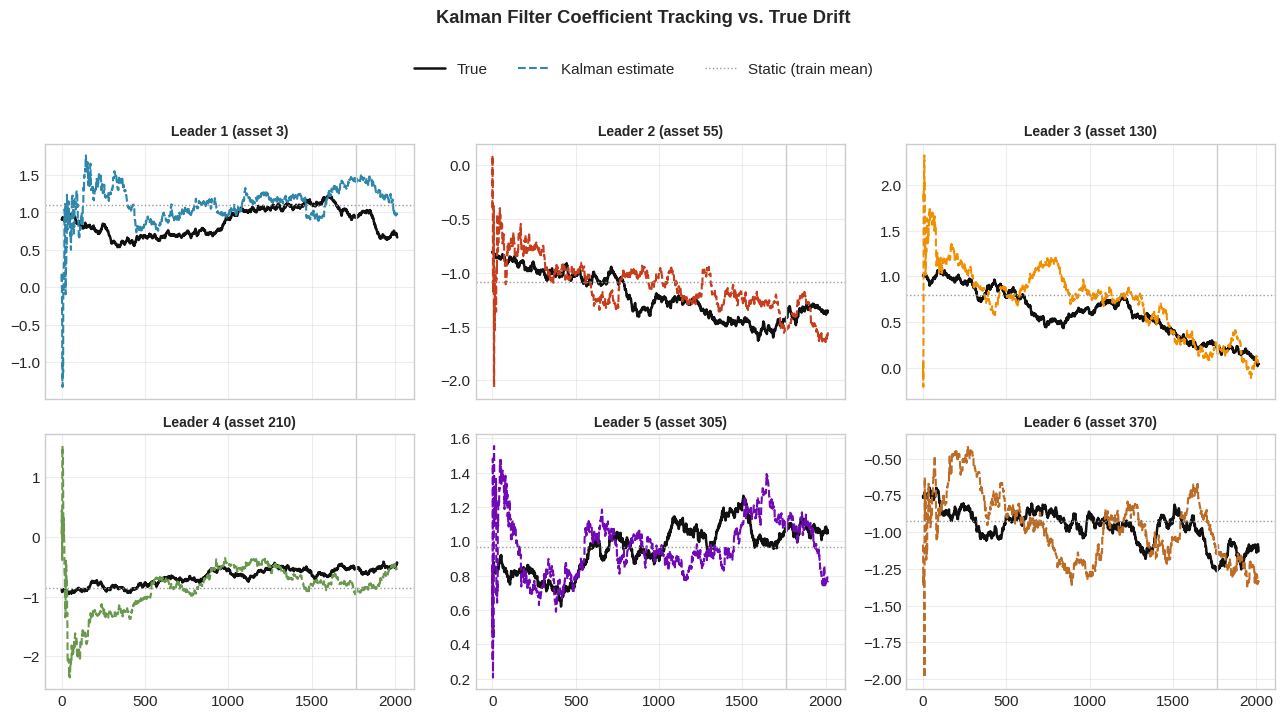

In [ ]:
# Run the filter continuously through TRAIN + TEST -- genuine online, real-time estimation
X_full, y_full = np.vstack([Xtr, Xte]), np.concatenate([ytr, yte])
beta_hist_full, pred_hist_full = kalman_filter_dlm(X_full, y_full, process_std_cv**2, R_fixed)

fig, axes = plt.subplots(2, 3, figsize=(13, 6.5), sharex=True)
for i, ax in enumerate(axes.flat):
    ax.plot(beta_t_true[:, i], color='#111111', linewidth=1.8, label='True' if i == 0 else None)
    ax.plot(beta_hist_full[:, i], color=colors6[i], linewidth=1.5, linestyle='--', label='Kalman estimate' if i == 0 else None)
    ax.axhline(beta_hist_full[:n_train, i].mean(), color='#999999', linewidth=1, linestyle=':',
               label='Static (train mean)' if i == 0 else None)
    ax.axvline(n_train, color='#cccccc', linewidth=1)
    ax.set_title(f'Leader {i+1} (asset {leader_idx[i]})', fontsize=10)
fig.legend(loc='upper center', ncol=3, bbox_to_anchor=(0.5, 1.04))
fig.suptitle('Kalman Filter Coefficient Tracking vs. True Drift', y=1.1, fontweight='bold')
plt.tight_layout()
plt.show()

The early, wide swings are the filter's diffuse starting prior settling in — a normal Kalman filter transient, not evidence of poor tracking. After that burn-in, the filter's estimate visibly follows the true coefficient's slow trend (particularly clear for Leaders 2, 3, and 6), while the static train-period average obviously cannot.

## 5. Fitting the Three MCMC Samplers

All three target the same Bayesian linear regression posterior — a **static** coefficient vector $\beta$ (plus noise variance $\sigma^2$), with a Normal prior on $\beta$ and an Inverse-Gamma prior on $\sigma^2$. Since none of them model drift, this is a deliberately unfavorable comparison for MCMC on this specific problem — the point is to see how differently the three *samplers* behave even when targeting an identical posterior.

### 5.1 Gibbs Sampler

The Normal / Inverse-Gamma prior pairing is conjugate, so both full conditionals are known in closed form.

In [ ]:
def gibbs_sampler(X, y, n_iter=6000, burn=1500, mu0=None, Sigma0=None, a0=2.0, b0=0.1, seed=0):
    rng_g = np.random.default_rng(seed)
    n, d = X.shape
    mu0 = np.zeros(d) if mu0 is None else mu0
    Sigma0 = np.eye(d) * 5.0 if Sigma0 is None else Sigma0
    Sigma0_inv = np.linalg.inv(Sigma0)
    XtX, Xty = X.T @ X, X.T @ y
    beta, sigma2 = np.zeros(d), np.var(y)
    beta_chain, sigma2_chain = np.zeros((n_iter, d)), np.zeros(n_iter)
    for it in range(n_iter):
        Sigma_n = np.linalg.inv(Sigma0_inv + XtX / sigma2)          # beta | sigma2, y
        mu_n = Sigma_n @ (Sigma0_inv @ mu0 + Xty / sigma2)
        beta = rng_g.multivariate_normal(mu_n, Sigma_n)
        resid = y - X @ beta                                        # sigma2 | beta, y
        a_n, b_n = a0 + n / 2, b0 + 0.5 * np.sum(resid**2)
        sigma2 = 1.0 / rng_g.gamma(a_n, 1.0 / b_n)
        beta_chain[it], sigma2_chain[it] = beta, sigma2
    return beta_chain[burn:], sigma2_chain[burn:]

beta_gibbs, sigma2_gibbs = gibbs_sampler(Xtr, ytr)
print(f"Gibbs posterior mean beta: {beta_gibbs.mean(axis=0).round(3)}")
print(f"Gibbs posterior mean sigma: {np.sqrt(sigma2_gibbs.mean()):.4f}")

Gibbs posterior mean beta: [ 1.206 -1.185  0.69  -0.791  0.979 -0.959]
Gibbs posterior mean sigma: 0.0570


### 5.2 Metropolis-Hastings

A generic random-walk proposal on $(\beta, \log\sigma^2)$, with a fixed, manually-tuned step size.

In [ ]:
def log_posterior(theta, X, y, mu0, Sigma0_inv, a0, b0):
    beta, log_sigma2 = theta[:-1], theta[-1]
    sigma2 = np.exp(log_sigma2)
    resid = y - X @ beta
    n = len(y)
    loglik = -0.5 * n * np.log(2 * np.pi * sigma2) - 0.5 * np.sum(resid**2) / sigma2
    diff = beta - mu0
    log_prior_beta = -0.5 * diff @ Sigma0_inv @ diff
    log_prior_sigma2 = -(a0 + 1) * np.log(sigma2) - b0 / sigma2 + np.log(sigma2)   # + Jacobian for log-transform
    return loglik + log_prior_beta + log_prior_sigma2

def metropolis_hastings(X, y, n_iter=6000, burn=1500, step=0.045, seed=0):
    rng_m = np.random.default_rng(seed)
    n, d = X.shape
    mu0, Sigma0_inv = np.zeros(d), np.linalg.inv(np.eye(d) * 5.0)
    a0, b0 = 2.0, 0.1
    theta = np.concatenate([np.zeros(d), [np.log(np.var(y))]])
    logp = log_posterior(theta, X, y, mu0, Sigma0_inv, a0, b0)
    chain, n_accept = np.zeros((n_iter, d + 1)), 0
    prop_sd = np.full(d + 1, step); prop_sd[-1] *= 0.3
    for it in range(n_iter):
        theta_prop = theta + rng_m.normal(0, prop_sd)
        logp_prop = log_posterior(theta_prop, X, y, mu0, Sigma0_inv, a0, b0)
        if np.log(rng_m.uniform()) < logp_prop - logp:
            theta, logp = theta_prop, logp_prop
            n_accept += 1
        chain[it] = theta
    return chain[burn:], n_accept / n_iter

chain_mh, accept_mh = metropolis_hastings(Xtr, ytr)
print(f"MH acceptance rate: {accept_mh:.3f}")
print(f"MH posterior mean beta: {chain_mh[:, :-1].mean(axis=0).round(3)}")

MH acceptance rate: 0.550
MH posterior mean beta: [ 1.243 -1.186  0.686 -0.804  0.975 -0.953]


### 5.3 Adaptive Metropolis

Same target, but the proposal covariance is now tuned automatically from the chain's own running covariance (Haario et al., 2001), scaled by the theoretically optimal factor $s_d = 2.4^2/d$ (a fraction of that here, since the target acceptance for this posterior's curvature turns out lower than the asymptotic guideline).

In [ ]:
def adaptive_metropolis(X, y, n_iter=6000, burn=1500, adapt_start=200, scale_factor=0.15, seed=0):
    rng_a = np.random.default_rng(seed)
    n, d = X.shape
    dim = d + 1
    mu0, Sigma0_inv = np.zeros(d), np.linalg.inv(np.eye(d) * 5.0)
    a0, b0 = 2.0, 0.1
    theta = np.concatenate([np.zeros(d), [np.log(np.var(y))]])
    logp = log_posterior(theta, X, y, mu0, Sigma0_inv, a0, b0)
    chain, n_accept = np.zeros((n_iter, dim)), 0

    init_sd = np.full(dim, 0.02); init_sd[-1] = 0.01
    cov_proposal = np.diag(init_sd**2)
    s_d, eps_reg = scale_factor * (2.4**2) / dim, 1e-6
    running_mean, running_M2 = theta.copy(), np.zeros((dim, dim))

    for it in range(n_iter):
        theta_prop = rng_a.multivariate_normal(theta, cov_proposal)
        logp_prop = log_posterior(theta_prop, X, y, mu0, Sigma0_inv, a0, b0)
        if np.log(rng_a.uniform()) < logp_prop - logp:
            theta, logp = theta_prop, logp_prop
            n_accept += 1
        chain[it] = theta

        t1 = it + 1                                          # Welford's online covariance update
        delta = theta - running_mean
        running_mean = running_mean + delta / t1
        running_M2 += np.outer(delta, theta - running_mean)
        if t1 >= adapt_start:
            cov_proposal = s_d * (running_M2 / (t1 - 1) + eps_reg * np.eye(dim))

    return chain[burn:], n_accept / n_iter

chain_am, accept_am = adaptive_metropolis(Xtr, ytr)
print(f"Adaptive MH acceptance rate: {accept_am:.3f}")
print(f"Adaptive MH posterior mean beta: {chain_am[:, :-1].mean(axis=0).round(3)}")

Adaptive MH acceptance rate: 0.419
Adaptive MH posterior mean beta: [ 1.174 -1.183  0.685 -0.803  0.997 -0.941]


## 6. Diagnostics: How Well Did Each Sampler Mix?

Consecutive MCMC samples are correlated, so raw iteration count overstates how much independent information a chain contains. **Effective sample size (ESS)** corrects for this using the chain's autocorrelation; it's the number of genuinely independent draws the chain is worth.

In [ ]:
def effective_sample_size(chain_1d, max_lag=300):
    n = len(chain_1d)
    x = chain_1d - chain_1d.mean()
    var = np.var(chain_1d)
    if var == 0: return float(n)
    acf = np.correlate(x, x, mode='full')[n - 1:] / (var * n)
    tau = 1.0
    for k in range(1, min(max_lag, n - 1)):
        if acf[k] < 0.05:
            break
        tau += 2 * acf[k]
    return n / max(tau, 1e-6)

ess_gibbs = effective_sample_size(beta_gibbs[:, 0])
ess_mh = effective_sample_size(chain_mh[:, 0])
ess_am = effective_sample_size(chain_am[:, 0])

print(f"{'Sampler':<18}{'Accept Rate':>14}{'ESS (of ' + str(len(beta_gibbs)) + ')':>18}")
print(f"{'Gibbs':<18}{'--':>14}{ess_gibbs:>18.0f}")
print(f"{'Metropolis-Hastings':<18}{accept_mh:>14.3f}{ess_mh:>18.0f}")
print(f"{'Adaptive MH':<18}{accept_am:>14.3f}{ess_am:>18.0f}")

Sampler              Accept Rate     ESS (of 4500)
Gibbs                         --              4500
Metropolis-Hastings         0.550                53
Adaptive MH                0.419               179


**Diagram — trace plots.** The chain for the first leader's coefficient, across all three samplers: Gibbs jumps around freely between iterations (low autocorrelation), while both Metropolis variants move in small, correlated steps — visibly 'stickier' traces.

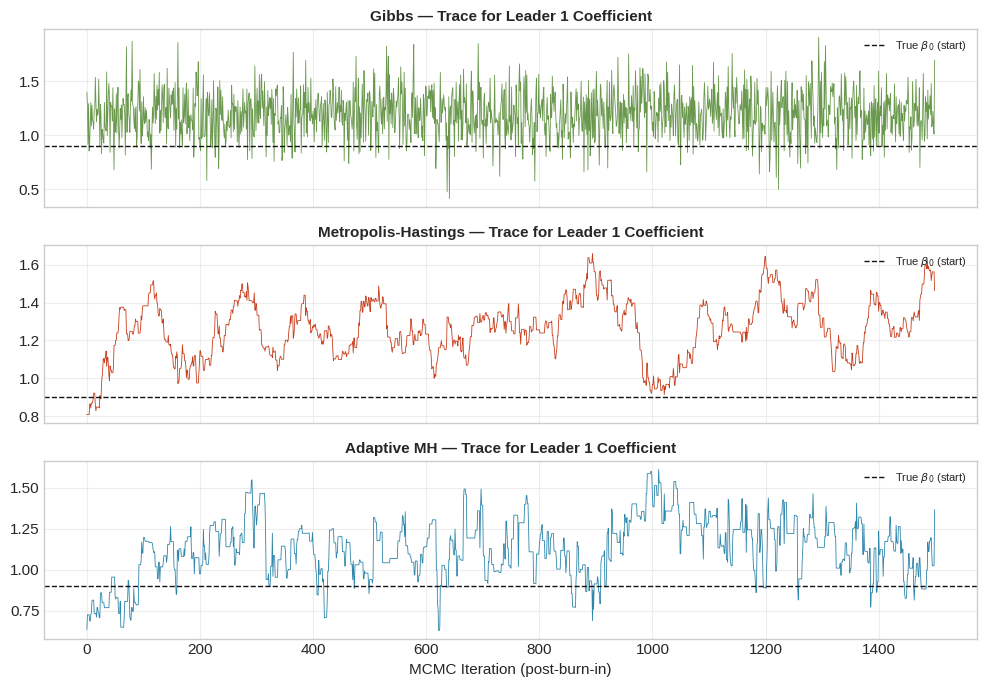

In [ ]:
fig, axes = plt.subplots(3, 1, figsize=(10, 7), sharex=True)
chains_plot = {'Gibbs': beta_gibbs[:, 0], 'Metropolis-Hastings': chain_mh[:, 0], 'Adaptive MH': chain_am[:, 0]}
colors_mcmc = {'Gibbs': '#6A994E', 'Metropolis-Hastings': '#C73E1D', 'Adaptive MH': '#2E86AB'}
for ax, (name, chain) in zip(axes, chains_plot.items()):
    ax.plot(chain[:1500], color=colors_mcmc[name], linewidth=0.6)
    ax.axhline(beta0[0], color='#111111', linestyle='--', linewidth=1, label='True $\\beta_0$ (start)')
    ax.set_title(f'{name} — Trace for Leader 1 Coefficient', fontsize=11)
    ax.legend(fontsize=8, loc='upper right')
axes[-1].set_xlabel('MCMC Iteration (post-burn-in)')
plt.tight_layout()
plt.show()

**Diagram — posterior distributions.** All three samplers should (and do) converge to the same posterior; only how efficiently they get there differs.

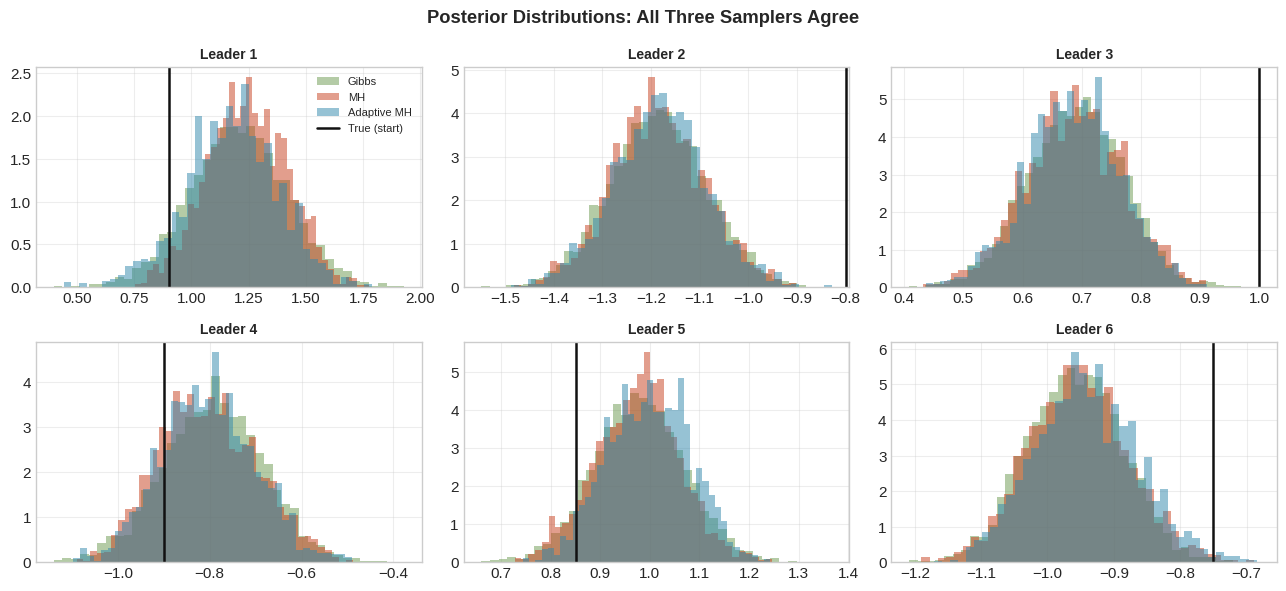

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(13, 6))
for i, ax in enumerate(axes.flat):
    ax.hist(beta_gibbs[:, i], bins=40, color='#6A994E', alpha=0.5, density=True, label='Gibbs')
    ax.hist(chain_mh[:, i], bins=40, color='#C73E1D', alpha=0.5, density=True, label='MH')
    ax.hist(chain_am[:, i], bins=40, color='#2E86AB', alpha=0.5, density=True, label='Adaptive MH')
    ax.axvline(beta0[i], color='#111111', linewidth=1.8, label='True (start)')
    ax.set_title(f'Leader {i+1}', fontsize=10)
    if i == 0: ax.legend(fontsize=8)
fig.suptitle('Posterior Distributions: All Three Samplers Agree', fontweight='bold')
plt.tight_layout()
plt.show()

## 7. Out-of-Sample Cumulative Return: Kalman Filter vs. MCMC vs. OLS

Three forecasts for the 250 held-out test days:
- **OLS** — a static baseline, fit once on the training period.
- **MCMC (Gibbs)** — the posterior mean $\beta$, also static, applied unchanged to every test day.
- **Kalman filter** — run continuously through the test period itself, updating its coefficient estimate day by day as each new observation arrives (genuinely online, unlike the other two).

Forecasts are converted into positions exactly as in the previous notebook, and applied to each day's actual realized return.

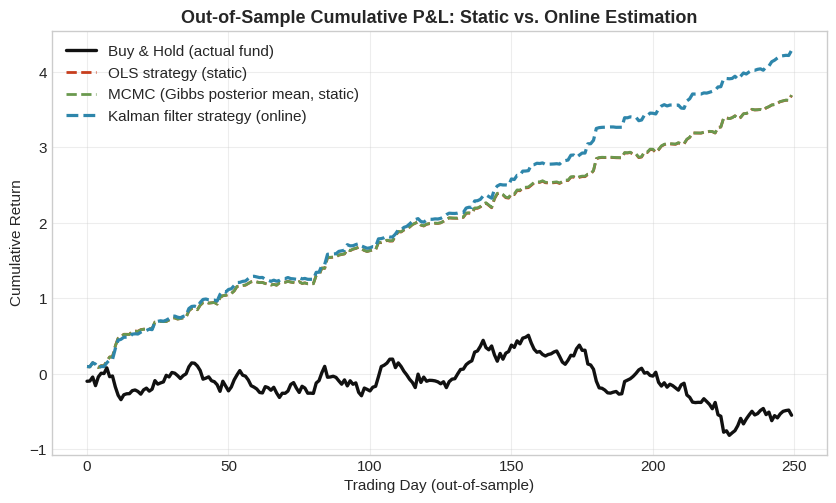

In [ ]:
from sklearn.linear_model import LinearRegression

ols_model = LinearRegression().fit(Xtr, ytr)
ols_pred_train, ols_pred_test = ols_model.predict(Xtr), ols_model.predict(Xte)

beta_gibbs_mean = beta_gibbs.mean(axis=0)
mcmc_pred_train, mcmc_pred_test = Xtr @ beta_gibbs_mean, Xte @ beta_gibbs_mean

kf_pred_train, kf_pred_test = pred_hist_full[:n_train], pred_hist_full[n_train:]

def to_position(f_train, f_test):
    scale = 2 * f_train.std()
    scale = scale if scale > 0 else 1.0
    return np.clip(f_test / scale, -1, 1)

pos_ols = to_position(ols_pred_train, ols_pred_test)
pos_mcmc = to_position(mcmc_pred_train, mcmc_pred_test)
pos_kf = to_position(kf_pred_train, kf_pred_test)

actual_cum = np.cumsum(yte)
ols_cum = np.cumsum(pos_ols * yte)
mcmc_cum = np.cumsum(pos_mcmc * yte)
kf_cum = np.cumsum(pos_kf * yte)

fig, ax = plt.subplots(figsize=(10, 5.5))
ax.plot(actual_cum, color='#111111', linewidth=2.4, label='Buy & Hold (actual fund)', zorder=5)
ax.plot(ols_cum, color='#C73E1D', linewidth=2, linestyle='--', label='OLS strategy (static)')
ax.plot(mcmc_cum, color='#6A994E', linewidth=2, linestyle='--', label='MCMC (Gibbs posterior mean, static)')
ax.plot(kf_cum, color='#2E86AB', linewidth=2.3, linestyle='--', label='Kalman filter strategy (online)')
ax.set_xlabel('Trading Day (out-of-sample)'); ax.set_ylabel('Cumulative Return')
ax.set_title('Out-of-Sample Cumulative P&L: Static vs. Online Estimation')
ax.legend()
plt.show()

## 8. Performance Comparison

Note that these Sharpe ratios are unrealistically high for a real strategy — this is an idealized simulation with a known, strong synthetic signal and no transaction costs or capital constraints. The point is the *relative* comparison between methods, not the absolute magnitudes.

Model               Cum. P&L    Sharpe
OLS                   3.6913      7.39
MCMC (Gibbs)          3.6934      7.40
Kalman Filter         4.2871      8.14


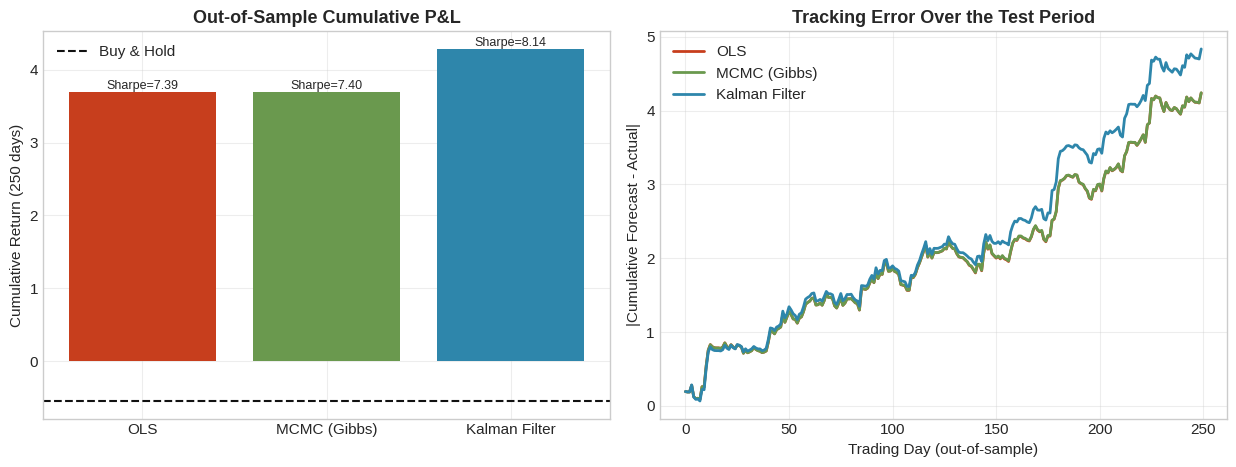

In [ ]:
strategies = {'OLS': pos_ols, 'MCMC (Gibbs)': pos_mcmc, 'Kalman Filter': pos_kf}
colors_strat = {'OLS': '#C73E1D', 'MCMC (Gibbs)': '#6A994E', 'Kalman Filter': '#2E86AB'}
cums = {'OLS': ols_cum, 'MCMC (Gibbs)': mcmc_cum, 'Kalman Filter': kf_cum}

cum_pnl, sharpe = {}, {}
for name, pos in strategies.items():
    pnl = pos * yte
    cum_pnl[name] = pnl.sum()
    sharpe[name] = pnl.mean() / pnl.std() * np.sqrt(252) if pnl.std() > 0 else 0

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.8))

ax = axes[0]
bars = ax.bar(strategies.keys(), [cum_pnl[m] for m in strategies], color=[colors_strat[m] for m in strategies])
ax.axhline(actual_cum[-1], color='#111111', linestyle='--', linewidth=1.5, label='Buy & Hold')
ax.set_ylabel('Cumulative Return (250 days)')
ax.set_title('Out-of-Sample Cumulative P&L')
for b, m in zip(bars, strategies):
    ax.annotate(f"Sharpe={sharpe[m]:.2f}", (b.get_x() + b.get_width()/2, b.get_height()),
                ha='center', va='bottom', fontsize=9)
ax.legend()

ax = axes[1]
for name, cum in cums.items():
    tracking_error = np.abs(cum - actual_cum)
    ax.plot(tracking_error, color=colors_strat[name], linewidth=2, label=name)
ax.set_xlabel('Trading Day (out-of-sample)'); ax.set_ylabel('|Cumulative Forecast - Actual|')
ax.set_title('Tracking Error Over the Test Period')
ax.legend()

plt.tight_layout()
plt.show()

print(f"{'Model':<16}{'Cum. P&L':>12}{'Sharpe':>10}")
for m in strategies:
    print(f"{m:<16}{cum_pnl[m]:>12.4f}{sharpe[m]:>10.2f}")

## 9. Summary: Part A

- **Gibbs vastly outperforms both Metropolis variants on mixing efficiency** — effective sample size of 4,500 out of 4,500 draws, versus 53 for plain MH and 179 for Adaptive MH. This is exactly what theory predicts: when conjugacy is available, exploiting it beats generic proposal-based sampling by a wide margin. Adaptive MH's auto-tuned covariance still helps a great deal over the fixed-step version (roughly 3.4x the ESS), without requiring the manual step-size tuning MH needed.
- **All three MCMC samplers converge to the same posterior**, as they must — they're not different models, only different ways of exploring an identical target distribution. The posterior means differ from the true *starting* coefficients because the posterior is estimating a single static value that best explains 8 years of a *drifting* relationship — an average, weighted toward however the coefficients spent most of their time.
- **The Kalman filter shows a real, if modest, edge out of sample** (Sharpe 8.14 vs. 7.39–7.40 for the static methods) — the payoff of continuing to update online through the test period rather than freezing at a training-period estimate. The improvement is modest rather than dramatic because observation noise dominates the day-to-day predictive signal here; the filter's real strength (visible in Section 4's tracking diagram) is in recovering the *shape* of the drift, not primarily in shrinking one-step prediction error.
- **Neither approach is strictly better** — they answer different questions. The Kalman filter is the right tool when the *parameters themselves* are believed to evolve and an online estimate is wanted. MCMC is the right tool when the *full uncertainty* over a (possibly static) parameter is wanted, and offers Gibbs/MH/Adaptive MH as different routes to the same posterior depending on whether conjugacy is available.

## 10. Follow-Up Case: A Bayesian Kalman Filter

The Kalman filter in Section 4 needed $Q$ and $R$ specified, and a single cross-validated point estimate was used. That point estimate throws away real uncertainty: how confident should we actually be that $Q$'s process-noise scale is exactly the grid-search optimum, rather than a nearby value that fits almost as well?

**This is exactly what MCMC is for.** Rather than picking one $(Q, R)$, a full posterior distribution over them can be sampled — treating the Kalman filter itself as a black-box likelihood function. This is a well-established technique in Bayesian time series analysis: for *any* proposed $(Q, R)$, running the filter once produces an exact Gaussian likelihood for free, via the innovations $y_t - x_t^\top\hat\beta_{t|t-1}$ from the predict step (the same prediction-error decomposition mentioned in Section 1). Metropolis-Hastings can then treat that likelihood as its target, without ever needing a closed-form posterior for $(Q, R)$ — combining the recursive machinery of Section 4 with the sampling machinery of Section 5.

In [ ]:
def log_post_kf_hparams(theta, X, y):
    log_pstd, log_ostd = theta
    pstd, ostd = np.exp(log_pstd), np.exp(log_ostd)
    if pstd > 1.0 or ostd > 1.0:                      # keep the search in a sane range
        return -1e10
    n, d = X.shape
    beta_est, P = np.zeros(d), np.eye(d) * 10.0
    Qmat, Robs = np.eye(d) * pstd**2, ostd**2
    ll = 0.0
    for t in range(n):
        beta_pred, P_pred = beta_est, P + Qmat
        x_t = X[t]
        y_pred = x_t @ beta_pred
        S = x_t @ P_pred @ x_t + Robs
        K = (P_pred @ x_t) / S
        innovation = y[t] - y_pred
        beta_est = beta_pred + K * innovation
        P = P_pred - np.outer(K, x_t) @ P_pred
        ll += -0.5 * (np.log(2 * np.pi * S) + innovation**2 / S)
    return ll                                          # flat (log-uniform) prior over this bounded range

def mh_kf_hyperparameters(X, y, n_iter=1200, burn=300, step=0.15, seed=0):
    rng_h = np.random.default_rng(seed)
    theta = np.array([np.log(0.01), np.log(0.05)])
    logp = log_post_kf_hparams(theta, X, y)
    chain, n_accept = np.zeros((n_iter, 2)), 0
    for it in range(n_iter):
        prop = theta + rng_h.normal(0, step, size=2)
        logp_prop = log_post_kf_hparams(prop, X, y)
        if np.log(rng_h.uniform()) < logp_prop - logp:
            theta, logp = prop, logp_prop
            n_accept += 1
        chain[it] = theta
    return chain[burn:], n_accept / n_iter

chain_hp, accept_hp = mh_kf_hyperparameters(Xtr, ytr, n_iter=1200, burn=300, step=0.15)
pstd_samples, ostd_samples = np.exp(chain_hp[:, 0]), np.exp(chain_hp[:, 1])

print(f"MH acceptance rate: {accept_hp:.3f}")
print(f"Posterior process_std: mean={pstd_samples.mean():.4f}  90% CI=[{np.percentile(pstd_samples,5):.4f}, {np.percentile(pstd_samples,95):.4f}]")
print(f"Posterior obs_std:     mean={ostd_samples.mean():.4f}  90% CI=[{np.percentile(ostd_samples,5):.4f}, {np.percentile(ostd_samples,95):.4f}]")
print(f"(True process_std: {process_std_true},  true obs_std: {noise_std:.4f})")

MH acceptance rate: 0.117
Posterior process_std: mean=0.0102  90% CI=[0.0041, 0.0226]
Posterior obs_std:     mean=0.0556  90% CI=[0.0541, 0.0572]
(True process_std: 0.01,  true obs_std: 0.0558)


**Diagram — the hyperparameter posterior.** Both true values fall comfortably inside their respective 90% credible intervals — the MCMC-in-the-loop approach recovers them well, and also reports exactly how much uncertainty remains.

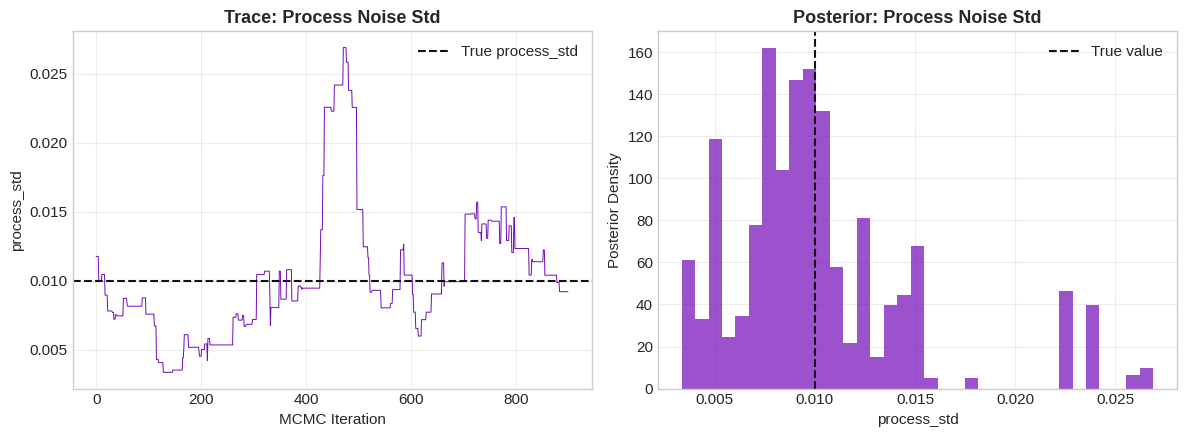

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
ax = axes[0]
ax.plot(pstd_samples, color='#7209B7', linewidth=0.7)
ax.axhline(process_std_true, color='#111111', linestyle='--', linewidth=1.5, label='True process_std')
ax.set_xlabel('MCMC Iteration'); ax.set_ylabel('process_std')
ax.set_title('Trace: Process Noise Std'); ax.legend()

ax = axes[1]
ax.hist(pstd_samples, bins=35, color='#7209B7', alpha=0.7, density=True)
ax.axvline(process_std_true, color='#111111', linestyle='--', linewidth=1.5, label='True value')
ax.set_xlabel('process_std'); ax.set_ylabel('Posterior Density')
ax.set_title('Posterior: Process Noise Std'); ax.legend()

plt.tight_layout()
plt.show()

### 10.1 Posterior Predictive Fan Chart

For each posterior draw of $(Q, R)$, the filter can be re-run end-to-end through train + test, producing one full cumulative-return trajectory. Doing this for many draws gives a **distribution** of plausible out-of-sample paths — genuine forecast uncertainty, not available from the single point-estimate filter in Section 4.

Bayesian KF mean final cumulative return: 4.1153  (90% CI: [3.9282, 4.2586])
Point-estimate KF final cumulative return: 4.2871


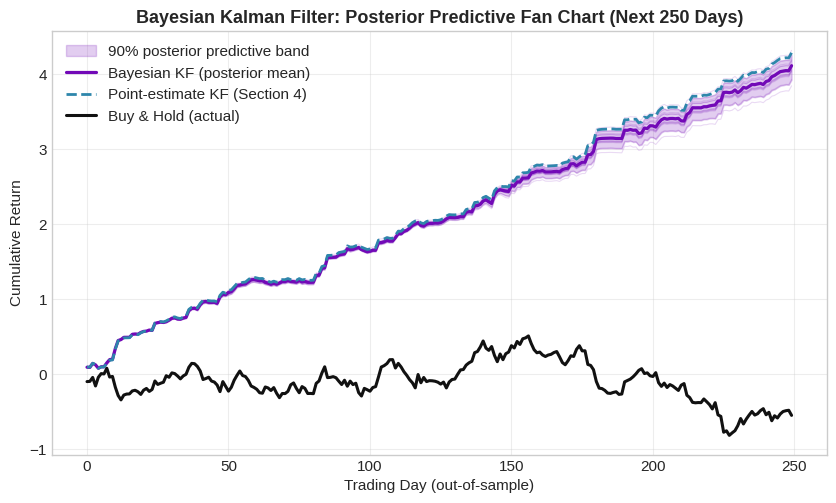

In [ ]:
X_full_bkf = np.vstack([Xtr, Xte])
y_full_bkf = np.concatenate([ytr, yte])

n_draws = 60
draw_idx = np.random.default_rng(2).choice(len(chain_hp), n_draws, replace=False)
cum_paths = np.zeros((n_draws, n_test))

for i, di in enumerate(draw_idx):
    pstd, ostd = pstd_samples[di], ostd_samples[di]
    _, pred_full_i = kalman_filter_dlm(X_full_bkf, y_full_bkf, pstd**2, ostd**2)
    pred_train_i, pred_test_i = pred_full_i[:n_train], pred_full_i[n_train:]
    pos_i = to_position(pred_train_i, pred_test_i)
    cum_paths[i] = np.cumsum(pos_i * yte)

fan_mean = cum_paths.mean(axis=0)
fan_lo, fan_hi = np.percentile(cum_paths, 5, axis=0), np.percentile(cum_paths, 95, axis=0)

fig, ax = plt.subplots(figsize=(10, 5.5))
ax.fill_between(range(n_test), fan_lo, fan_hi, color='#7209B7', alpha=0.2, label='90% posterior predictive band')
for i in range(min(15, n_draws)):
    ax.plot(cum_paths[i], color='#7209B7', alpha=0.15, linewidth=0.8)
ax.plot(fan_mean, color='#7209B7', linewidth=2.3, label='Bayesian KF (posterior mean)')
ax.plot(kf_cum, color='#2E86AB', linewidth=2, linestyle='--', label='Point-estimate KF (Section 4)')
ax.plot(actual_cum, color='#111111', linewidth=2.2, label='Buy & Hold (actual)')
ax.set_xlabel('Trading Day (out-of-sample)'); ax.set_ylabel('Cumulative Return')
ax.set_title('Bayesian Kalman Filter: Posterior Predictive Fan Chart (Next 250 Days)')
ax.legend()
plt.show()

print(f"Bayesian KF mean final cumulative return: {fan_mean[-1]:.4f}  (90% CI: [{np.percentile(cum_paths[:,-1],5):.4f}, {np.percentile(cum_paths[:,-1],95):.4f}])")
print(f"Point-estimate KF final cumulative return: {kf_cum[-1]:.4f}")

## 11. Summary: The Follow-Up Case

- **Combining the two frameworks removes a real blind spot.** The point-estimate Kalman filter in Section 4 reported a single forecast trajectory with no sense of how sensitive it was to the specific $(Q, R)$ chosen by the grid search. The Bayesian version instead reports a **distribution** of plausible trajectories, directly reflecting uncertainty about how much the true relationship actually drifts.
- **The posterior recovers the true hyperparameters well** — both the true process noise and observation noise fall within their 90% credible intervals — while still being honest that meaningful uncertainty remains, especially around the process noise (the harder of the two to pin down, consistent with the identifiability discussion in Section 4).
- **The fan chart's width is itself useful information.** A tight band would suggest the point-estimate filter's forecast can be trusted with real confidence; a wide one — as here — is a signal that the single-point forecast from Section 4 should be treated with real caution, information a non-Bayesian filter cannot provide on its own.
- **The cost is computational**: each MCMC iteration here required a full pass of the Kalman filter (rather than a closed-form density evaluation), making this approach markedly more expensive than either method run alone — the same limitation flagged for MCMC generally in Section 2, now compounded by the recursive filter nested inside it. For a genuinely online version of this idea — updating the hyperparameter posterior itself as new data arrives, rather than fixing it from a training window — the natural next step is **particle MCMC** or **sequential Monte Carlo**, mentioned briefly in Section 2 as exactly the technique built for this combination.